Data Loading and Preprocessing


We will use Yahoo Finance stock data for LSTM based time series prediction.


In [1]:
!uv pip install yfinance scikit-learn matplotlib


Using Python 3.12.12 environment at: /usr
Audited 3 packages in 488ms


In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEQ_LEN = 60
BATCH_SIZE = 32

print(f"Device: {DEVICE}")


Device: cuda


In [4]:
def download_stock_data(ticker="AAPL", period="5y"):
    import yfinance as yf

    df = yf.download(ticker, period=period, auto_adjust=True)
    return df


In [5]:
TICKER = "AAPL"
df = download_stock_data(TICKER, period="5y")
prices = df["Close"].values.reshape(-1, 1).astype(np.float64)

print(df.head())
print(f"Total data points: {len(prices)}")


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-04-06  122.927971  123.824045  122.382536  123.210430   80171300
2021-04-07  124.574028  124.593505  121.885798  122.557858   83466700
2021-04-08  126.970062  126.999281  125.177914  125.596725   88844600
2021-04-09  129.541428  129.580381  126.103224  126.424644  106686700
2021-04-12  127.827194  129.395328  127.233056  129.073907   91420000
Total data points: 1256


In [6]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)

split = int(len(scaled) * 0.8)
train_data = scaled[:split]
test_data = scaled[split:]

print(f"Train points: {len(train_data)}")
print(f"Test points: {len(test_data)}")


Train points: 1004
Test points: 252


We use a sliding window approach to construct the stock price sequences.


In [7]:
class StockDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx: idx + self.seq_len], dtype=torch.float32)
        y = torch.tensor(self.data[idx + self.seq_len], dtype=torch.float32)
        return x, y


In [8]:
train_ds = StockDataset(train_data, SEQ_LEN)
test_ds = StockDataset(test_data, SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Train samples: {len(train_ds)}")
print(f"Test samples: {len(test_ds)}")


Train samples: 944
Test samples: 192


Model training


In [9]:
class StockLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


Training


In [10]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred.squeeze(), y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x)
        loss = criterion(pred.squeeze(), y.squeeze())
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


In [11]:
model = StockLSTM(input_size=1, hidden_size=64, num_layers=2).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 50
history = {"train_loss": [], "test_loss": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(model, train_loader, criterion, optimizer)
    te_loss = evaluate(model, test_loader, criterion)
    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.6f}  test_loss={te_loss:.6f}")


Epoch 1/50  train_loss=0.087549  test_loss=0.245879
Epoch 5/50  train_loss=0.002324  test_loss=0.003839
Epoch 10/50  train_loss=0.001534  test_loss=0.003390
Epoch 15/50  train_loss=0.001316  test_loss=0.004326
Epoch 20/50  train_loss=0.001149  test_loss=0.003163
Epoch 25/50  train_loss=0.001120  test_loss=0.002762
Epoch 30/50  train_loss=0.001059  test_loss=0.006536
Epoch 35/50  train_loss=0.000904  test_loss=0.002992
Epoch 40/50  train_loss=0.000860  test_loss=0.002165
Epoch 45/50  train_loss=0.000914  test_loss=0.001984
Epoch 50/50  train_loss=0.000762  test_loss=0.001821


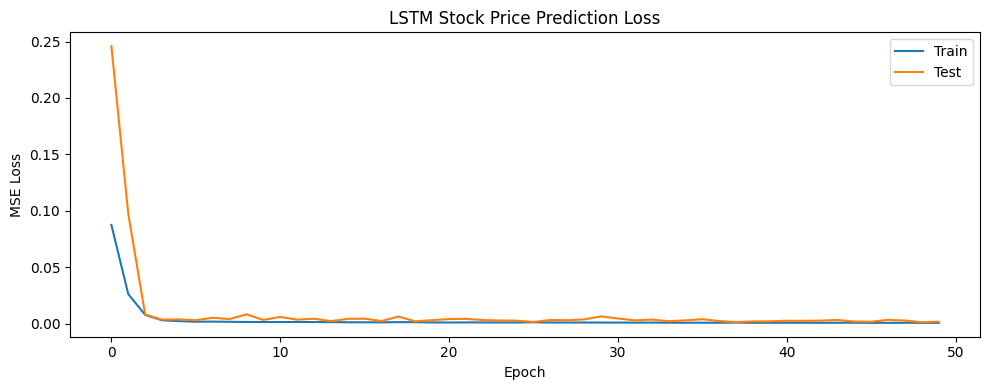

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["test_loss"], label="Test")
plt.title("LSTM Stock Price Prediction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


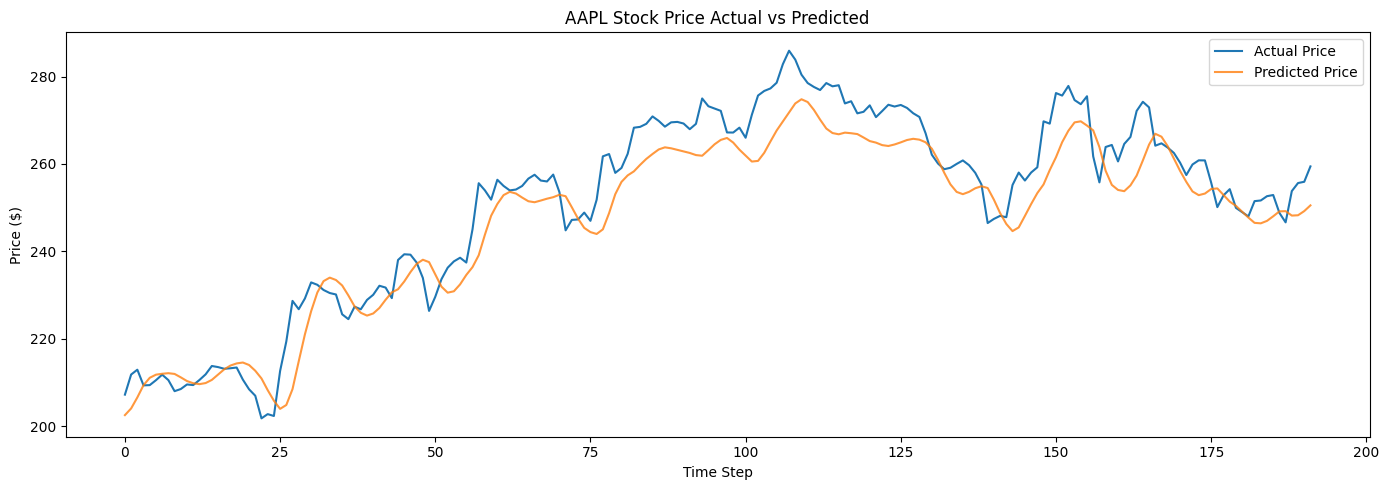

Ticker: AAPL
Sequence Length: 60
Epochs: 50
Train samples: 944
Test samples: 192
Final Train Loss (MSE): 0.000762
Final Test Loss (MSE): 0.001821
RMSE: 7.0906
MAE: 5.8329


In [13]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        pred = model(x).cpu().numpy()
        all_preds.append(pred)
        all_true.append(y.numpy())

all_preds = np.concatenate(all_preds).reshape(-1, 1)
all_true = np.concatenate(all_true).reshape(-1, 1)

pred_prices = scaler.inverse_transform(all_preds)
true_prices = scaler.inverse_transform(all_true)

plt.figure(figsize=(14, 5))
plt.plot(true_prices, label="Actual Price", linewidth=1.5)
plt.plot(pred_prices, label="Predicted Price", linewidth=1.5, alpha=0.8)
plt.title(f"{TICKER} Stock Price Actual vs Predicted")
plt.xlabel("Time Step")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((pred_prices - true_prices) ** 2))
mae = np.mean(np.abs(pred_prices - true_prices))

print(f"Ticker: {TICKER}")
print(f"Sequence Length: {SEQ_LEN}")
print(f"Epochs: {EPOCHS}")
print(f"Train samples: {len(train_ds)}")
print(f"Test samples: {len(test_ds)}")
print(f"Final Train Loss (MSE): {history['train_loss'][-1]:.6f}")
print(f"Final Test Loss (MSE): {history['test_loss'][-1]:.6f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


The LSTM was able to learn the patterns in the stock price data and make predictions. 